<a href="https://colab.research.google.com/github/Vijendarvjy/CNN_demo/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step-1 **Image** Upload and Resize 250x250

In [14]:
import os
from PIL import Image
import numpy as np

# Define the base input and output folders
base_input_folder = '/content/drive/MyDrive/image_data'
base_output_folder = '/content/outputImg'

# Define the subfolders to process
subfolders = ['mouse', 'keyboard']

# Target size for resizing
target_size = (250, 250)

# Create base folders if they don't exist
os.makedirs(base_input_folder, exist_ok=True)
os.makedirs(base_output_folder, exist_ok=True)

print(f"Base input folder: {base_input_folder}")
print(f"Base output folder: {base_output_folder}")
print(f"Subfolders to process: {subfolders}")

Base input folder: /content/drive/MyDrive/image_data
Base output folder: /content/outputImg
Subfolders to process: ['mouse', 'keyboard']


## Step-2 Create Dummy Data for Subfolder(IMG Augmentation)

In [15]:
for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_input_folder, subfolder_name)
    os.makedirs(input_subfolder_path, exist_ok=True)

    if not os.listdir(input_subfolder_path):
        print(f"Input subfolder '{input_subfolder_path}' is empty. Creating a dummy image.")
        dummy_image_path = os.path.join(input_subfolder_path, f'dummy_{subfolder_name}_data.png')
        dummy_image = Image.fromarray(np.uint8(np.random.rand(100, 100, 3) * 255))
        dummy_image.save(dummy_image_path)
        print(f"Created: {dummy_image_path}")
    else:
        print(f"Input subfolder '{input_subfolder_path}' is not empty. Skipping dummy data creation.")

Input subfolder '/content/drive/MyDrive/image_data/mouse' is not empty. Skipping dummy data creation.
Input subfolder '/content/drive/MyDrive/image_data/keyboard' is not empty. Skipping dummy data creation.


### Process and Resize Images with Subfolder Structure

This core processing block iterates through each specified subfolder. For each image found, it will:
1. Construct the full input and output paths, preserving the subfolder structure.
2. Open, resize, and save the image to the corresponding output subfolder.

Error handling is included to catch issues with specific image files.


Processing images in: /content/drive/MyDrive/image_data/mouse
  Resized 'm _2.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _1.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _4.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _3.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _5.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _6.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _7.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _10.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _8.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _9.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _12.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _11.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _13.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _14.jpeg' and saved to '/content/outputImg/mouse'.
  Resized 'm _15.jpeg' and saved to '/content/outp

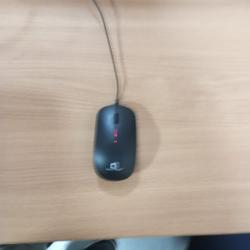

In [3]:
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
overall_processed_count = 0

for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_input_folder, subfolder_name)
    output_subfolder_path = os.path.join(base_output_folder, subfolder_name)

    os.makedirs(output_subfolder_path, exist_ok=True)

    print(f"\nProcessing images in: {input_subfolder_path}")
    processed_in_subfolder = 0
    for filename in os.listdir(input_subfolder_path):
        if filename.lower().endswith(image_extensions):
            input_path = os.path.join(input_subfolder_path, filename)
            output_path = os.path.join(output_subfolder_path, filename)

            try:
                with Image.open(input_path) as img:
                    resized_img = img.resize(target_size)
                    resized_img.save(output_path)
                    processed_in_subfolder += 1
                    overall_processed_count += 1
                    print(f"  Resized '{filename}' and saved to '{output_subfolder_path}'.")
            except Exception as e:
                print(f"  Error processing '{filename}': {e}")
    if processed_in_subfolder == 0:
        print(f"  No image files found or processed in '{input_subfolder_path}'.")

if overall_processed_count == 0:
    print("\nNo image files were processed across all specified subfolders.")
else:
    print(f"\nSuccessfully processed a total of {overall_processed_count} image(s).")

# Optional: Display one of the resized images from the first output subfolder to verify
if overall_processed_count > 0 and len(os.listdir(os.path.join(base_output_folder, subfolders[0]))) > 0:
    print("\nDisplaying one of the resized images:")
    first_output_subfolder = os.path.join(base_output_folder, subfolders[0])
    first_resized_image = os.listdir(first_output_subfolder)[0]
    display(Image.open(os.path.join(first_output_subfolder, first_resized_image)))

### Image Augmentation

Image augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of images from the existing dataset. It helps in preventing overfitting and improving the generalization ability of models.

We will use `torchvision.transforms` for this purpose. If `torch` or `torchvision` are not already installed, the following cell will install them.

In [4]:
# Install torchvision if not already installed
try:
    import torchvision
    print("torchvision is already installed.")
except ImportError:
    print("torchvision not found, installing...")
    !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 # or cpu
    import torchvision
    print("torchvision installed successfully.")

torchvision is already installed.


In [5]:
import torchvision.transforms as transforms

# Define the base input folder for augmentation (the output from previous step)
base_augmentation_input_folder = base_output_folder # /content/outputImg
# Define the base output folder for augmented images
base_augmentation_output_folder = '/content/augmented_outputImg'

os.makedirs(base_augmentation_output_folder, exist_ok=True)

print(f"Base input folder for augmentation: {base_augmentation_input_folder}")
print(f"Base output folder for augmented images: {base_augmentation_output_folder}")

# Define augmentation transformations
# These transformations will be applied to each image
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip the image horizontally
    transforms.RandomRotation(degrees=15),   # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2), # Randomly change brightness, contrast, saturation, and hue
    # transforms.ToTensor() # Convert PIL Image to PyTorch Tensor (not needed if we save as PIL)
])

# Number of augmented images to generate per original image
num_augmentations_per_image = 3 # Generate 3 augmented versions for each original image

Base input folder for augmentation: /content/outputImg
Base output folder for augmented images: /content/augmented_outputImg


### Apply Augmentation to Resized Images

This block will iterate through the previously resized images, apply the defined augmentations, and save the augmented images to the `base_augmentation_output_folder`.


Augmenting images in: /content/outputImg/mouse
  Augmented 'm _1.jpeg' to 'm _1_aug0.jpeg' and saved.
  Augmented 'm _1.jpeg' to 'm _1_aug1.jpeg' and saved.
  Augmented 'm _1.jpeg' to 'm _1_aug2.jpeg' and saved.
  Augmented 'm _28.jpeg' to 'm _28_aug0.jpeg' and saved.
  Augmented 'm _28.jpeg' to 'm _28_aug1.jpeg' and saved.
  Augmented 'm _28.jpeg' to 'm _28_aug2.jpeg' and saved.
  Augmented 'm _15.jpeg' to 'm _15_aug0.jpeg' and saved.
  Augmented 'm _15.jpeg' to 'm _15_aug1.jpeg' and saved.
  Augmented 'm _15.jpeg' to 'm _15_aug2.jpeg' and saved.
  Augmented 'm _20.jpeg' to 'm _20_aug0.jpeg' and saved.
  Augmented 'm _20.jpeg' to 'm _20_aug1.jpeg' and saved.
  Augmented 'm _20.jpeg' to 'm _20_aug2.jpeg' and saved.
  Augmented 'm _29.jpeg' to 'm _29_aug0.jpeg' and saved.
  Augmented 'm _29.jpeg' to 'm _29_aug1.jpeg' and saved.
  Augmented 'm _29.jpeg' to 'm _29_aug2.jpeg' and saved.
  Augmented 'm _27.jpeg' to 'm _27_aug0.jpeg' and saved.
  Augmented 'm _27.jpeg' to 'm _27_aug1.jpeg' 

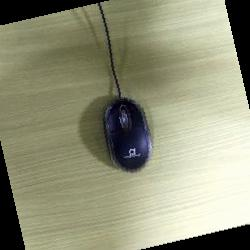

In [6]:
augmented_count = 0

for subfolder_name in subfolders:
    input_subfolder_path = os.path.join(base_augmentation_input_folder, subfolder_name)
    output_subfolder_path = os.path.join(base_augmentation_output_folder, subfolder_name)

    os.makedirs(output_subfolder_path, exist_ok=True)

    print(f"\nAugmenting images in: {input_subfolder_path}")

    # Check if the input subfolder actually exists and has images
    if not os.path.exists(input_subfolder_path) or not os.listdir(input_subfolder_path):
        print(f"  Input subfolder '{input_subfolder_path}' is empty or does not exist. Skipping augmentation for this subfolder.")
        continue

    for filename in os.listdir(input_subfolder_path):
        if filename.lower().endswith(image_extensions):
            original_image_path = os.path.join(input_subfolder_path, filename)

            try:
                with Image.open(original_image_path) as img:
                    for i in range(num_augmentations_per_image):
                        augmented_img = augmentation_transforms(img)

                        # Create a unique filename for each augmented image
                        name, ext = os.path.splitext(filename)
                        augmented_filename = f"{name}_aug{i}{ext}"
                        augmented_output_path = os.path.join(output_subfolder_path, augmented_filename)
                        augmented_img.save(augmented_output_path)
                        augmented_count += 1
                        print(f"  Augmented '{filename}' to '{augmented_filename}' and saved.")
            except Exception as e:
                print(f"  Error augmenting '{filename}': {e}")

if augmented_count == 0:
    print("\nNo images were augmented across all specified subfolders.")
else:
    print(f"\nSuccessfully generated a total of {augmented_count} augmented image(s).")

# Optional: Display one of the augmented images from the first output subfolder to verify
if augmented_count > 0 and len(os.listdir(os.path.join(base_augmentation_output_folder, subfolders[0]))) > 0:
    print("\nDisplaying one of the augmented images:")
    first_augmented_subfolder = os.path.join(base_augmentation_output_folder, subfolders[0])
    first_augmented_image = os.listdir(first_augmented_subfolder)[0]
    display(Image.open(os.path.join(first_augmented_subfolder, first_augmented_image)))

### Simple Image Classification using CNN

Now we'll build a basic Convolutional Neural Network (CNN) to classify the 'mouse' and 'keyboard' images. We'll use PyTorch for this. The steps involved are:
1.  **Load and Prepare Data**: Create PyTorch `Dataset` and `DataLoader` objects from the augmented images.
2.  **Define the CNN Model**: Construct a simple CNN architecture.
3.  **Define Training Function**: Set up the loss function, optimizer, and training loop.
4.  **Train and Evaluate**: Train the model and evaluate its performance.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
CUDA available: False
Using device: cpu


#### 1. Load and Prepare Data

We'll use `ImageFolder` to easily load our augmented dataset. We'll also define a final set of transformations, convert images to tensors, and normalize them for CNN input.

In [8]:
# Transformations for the dataset
# The images are already resized, so we just need to convert to tensor and normalize
dataset_transforms = transforms.Compose([
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Load the dataset using ImageFolder
# The root is our base_augmentation_output_folder
full_dataset = datasets.ImageFolder(root=base_augmentation_output_folder, transform=dataset_transforms)

# Split the dataset into training and testing sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total images in dataset: {len(full_dataset)}")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Class to index mapping: {full_dataset.class_to_idx}")

Total images in dataset: 162
Training images: 129
Testing images: 33
Classes: ['keyboard', 'mouse']
Class to index mapping: {'keyboard': 0, 'mouse': 1}


#### 2. Define the CNN Model

We'll create a simple CNN with a few convolutional layers followed by max-pooling, and then fully connected layers for classification.

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # Input: 3 channels (RGB), Output: 16 features
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduces image size by half (e.g., 250 -> 125)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # Input: 16 features, Output: 32 features
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces image size by half (e.g., 125 -> 62)
        )
        # Calculate the size of the feature map after convolutional layers
        # Our input images are 250x250. After two MaxPool2d layers with stride 2,
        # the spatial dimensions become 250 / 2 / 2 = 62.5, which will be 62 due to floor operation.
        # So, the size is 32 features * 62 * 62.
        self.classifier = nn.Sequential(
            nn.Flatten(), # Flatten the 3D feature map to a 1D vector
            nn.Linear(32 * 62 * 62, 128), # First fully connected layer
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout for regularization
            nn.Linear(128, num_classes) # Output layer with 2 classes (mouse, keyboard)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate the model and move it to the device (GPU/CPU)
model = SimpleCNN(num_classes=len(full_dataset.classes)).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=123008, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


#### 3. Define Training Parameters

We'll set up the loss function (CrossEntropyLoss for classification), the optimizer (Adam), and the number of training epochs.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

#### 4. Train the Model

This is the main training loop where the model learns from the data.

In [11]:
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct_predictions / total_predictions
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Finished Training")

Epoch [1/10], Loss: 3.1942, Accuracy: 53.49%
Epoch [2/10], Loss: 0.6583, Accuracy: 74.42%
Epoch [3/10], Loss: 0.3280, Accuracy: 87.60%
Epoch [4/10], Loss: 0.2026, Accuracy: 92.25%
Epoch [5/10], Loss: 0.0830, Accuracy: 96.12%
Epoch [6/10], Loss: 0.0496, Accuracy: 98.45%
Epoch [7/10], Loss: 0.0400, Accuracy: 98.45%
Epoch [8/10], Loss: 0.0055, Accuracy: 100.00%
Epoch [9/10], Loss: 0.0208, Accuracy: 99.22%
Epoch [10/10], Loss: 0.0039, Accuracy: 100.00%
Finished Training


#### 5. Evaluate the Model

Finally, let's evaluate the trained model on the test dataset to see how well it generalizes to unseen data.

Accuracy of the network on the 33 test images: 90.91%


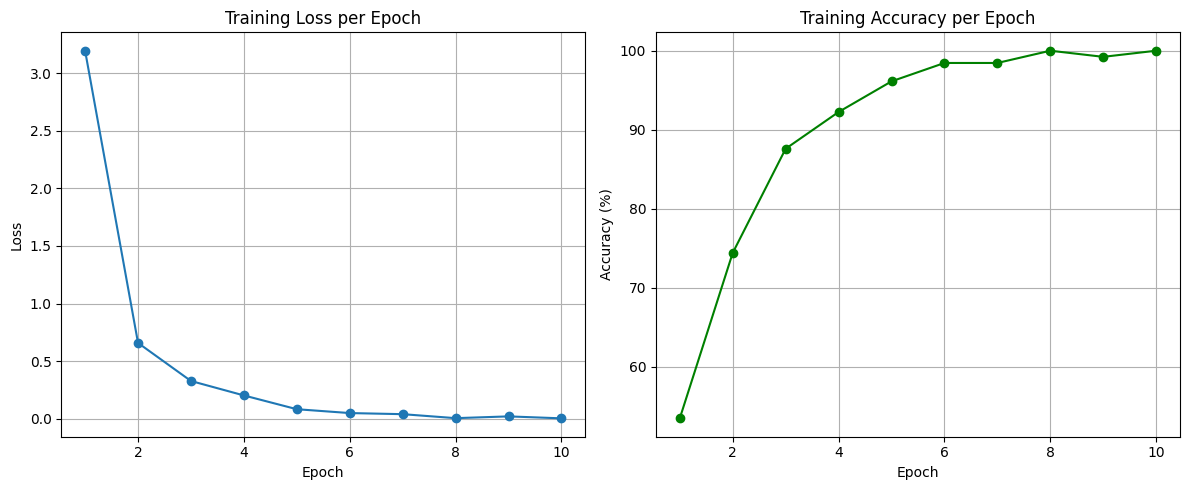

In [12]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # No need to calculate gradients during inference
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the {total} test images: {accuracy:.2f}%')

# Plotting training loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', color='green')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Test Model with a Single Image

This block allows you to test the trained CNN model on an individual image. It will:
1. Load a sample image (you can change the path to any image you want to test).
2. Apply the same preprocessing steps (ToTensor and Normalize) used during training.
3. Pass the preprocessed image through the trained model to get a prediction.
4. Display the image along with its predicted class.

Testing image: /content/augmented_outputImg/keyboard/k _9_aug0.jpeg


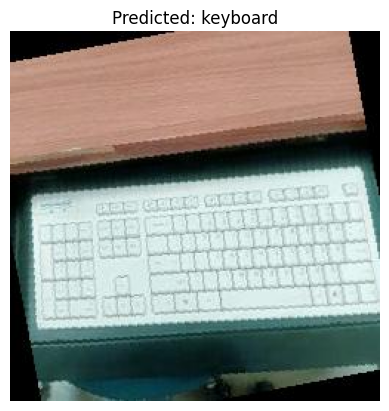

In [16]:
model.eval() # Set the model to evaluation mode

# Get class names from the dataset
class_names = full_dataset.classes

# --- Choose an image to test ---
# You can change this path to any image you want to test
# For demonstration, let's pick an augmented image from the mouse subfolder

try:
    sample_image_path = "/content/augmented_outputImg/keyboard/k _9_aug0.jpeg"
except IndexError:
    print("No images found in the augmented mouse folder. Please check your data.")
    sample_image_path = None

if sample_image_path:
    print(f"Testing image: {sample_image_path}")

    # Load the image
    image_to_test = Image.open(sample_image_path).convert('RGB')

    # Apply the same transformations as the dataset (ToTensor and Normalize)
    # Note: If your dataset_transforms included resizing, it's already handled because we pick from augmented output
    test_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = test_transforms(image_to_test)
    input_batch = input_tensor.unsqueeze(0) # Create a mini-batch as expected by the model

    # Move the input to the same device as the model
    input_batch = input_batch.to(device)

    with torch.no_grad():
        output = model(input_batch)

    # Get the predicted class
    _, predicted_idx = torch.max(output, 1)
    predicted_class = class_names[predicted_idx.item()]

    # Display the image and prediction
    plt.imshow(image_to_test)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("Skipping single image test due to missing sample image.")

### Save the Trained Model

Before deploying, we need to save the trained model's state dictionary. This will allow us to load the model later in our Streamlit application without retraining.

In [17]:
model_save_path = 'simple_cnn_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to simple_cnn_model.pth


### `requirements.txt`

This file lists all the Python packages required for your Streamlit application to run. You will need to create a file named `requirements.txt` in the same directory as your `app.py` with the following content:

In [18]:
requirements_content = """
torch
torchvision
pillow
streamlit
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("requirements.txt created.")
print("\nContent of requirements.txt:\n")
print(requirements_content)

requirements.txt created.

Content of requirements.txt:


torch
torchvision
pillow
streamlit



### `app.py`

This is the main script for your Streamlit application. It will load the saved model, define the necessary transformations, and create a user interface for image classification. You will need to create a file named `app.py` in the same directory as your `simple_cnn_model.pth` and `requirements.txt` with the following content:

In [20]:
app_py_content = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os

# Define the same CNN architecture as in training
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # The input features for the linear layer depend on the image size
            # Our images were 250x250, so after two MaxPool2d layers (stride 2),
            # the size becomes 250 / 4 = 62.5, which is floored to 62.
            nn.Linear(32 * 62 * 62, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Configuration
IMAGE_SIZE = (250, 250)
CLASS_NAMES = ['keyboard', 'mouse'] # Make sure this matches your dataset classes
MODEL_PATH = 'simple_cnn_model.pth' # Path to your saved model

# Load the trained model
@st.cache_resource
def load_model():
    model = SimpleCNN(num_classes=len(CLASS_NAMES))
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
    model.eval()
    return model

# Image transformations (must match training transformations)
def get_transforms():
    return transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Predict function
def predict(image, model, transform):
    image = image.convert('RGB')
    image_tensor = transform(image).unsqueeze(0) # Add batch dimension

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        _, predicted_idx = torch.max(output, 1)

    return CLASS_NAMES[predicted_idx.item()], probabilities[0][predicted_idx.item()].item()

# Streamlit app layout
st.title("Image Classifier: Keyboard vs. Mouse")
st.write("Upload an image and let the model predict if it's a keyboard or a mouse.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image.', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # Load model and transforms
    model = load_model()
    transform = get_transforms()

    # Make prediction
    predicted_class, confidence = predict(image, model, transform)

    st.success(f"Prediction: {predicted_class} (Confidence: {confidence:.2f})")

# How to run the app:
st.markdown("""
To run this Streamlit app locally, save the above content as `app.py` in the same directory as `simple_cnn_model.pth` and `requirements.txt`.
Then, open your terminal in that directory and run:
```bash
streamlit run app.py
```
"""
)
'''

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("app.py created.")
print("\nContent of app.py:\n")
print(app_py_content)

SyntaxError: invalid syntax (2301136057.py, line 93)